# 1 задание

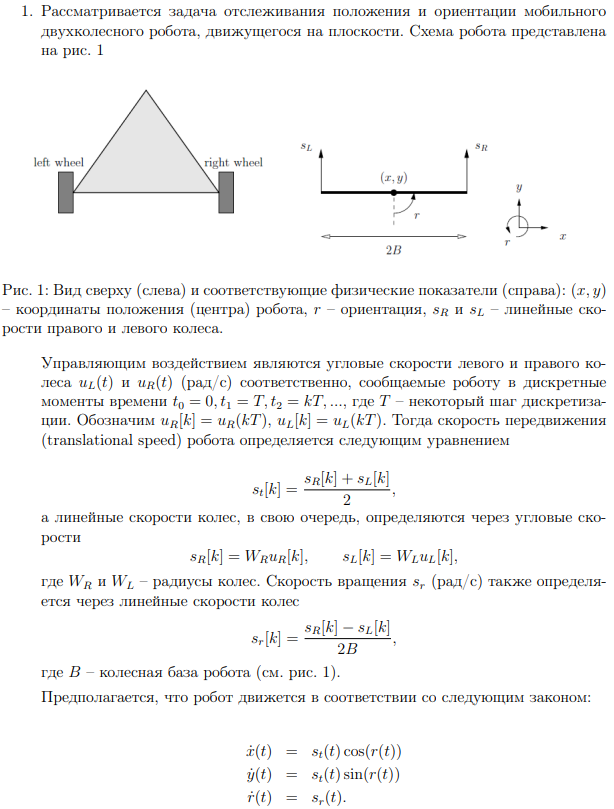
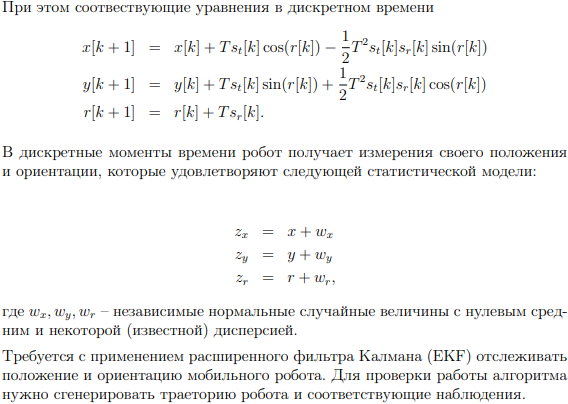

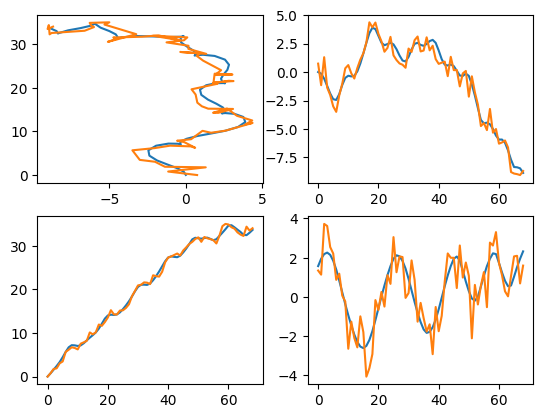

In [7]:
import numpy as np
import matplotlib.pyplot as plt


T = 1 # шаг времени
B = 2 # колесная база
W_L = 1.5 # Радиус левого колеса
W_R = 1 # радиус правого колеса

# угловые скорости левого колеса (рад/с)
u_L = np.array([
    0.0, 0.3, 0.6, 0.9, 1.2, 1.4, 1.5, 1.4, 1.2, 0.9, 0.6, 0.3,
    0.0, -0.3, -0.6, -0.9, -1.2, -1.4, -1.5, -1.4, -1.2, -0.9, -0.6, -0.3,
    0.0, 0.4, 0.8, 1.1, 1.3, 1.4, 1.3, 1.1, 0.8, 0.4, 0.0, -0.4,
    -0.8, -1.1, -1.3, -1.4, -1.3, -1.1, -0.8, -0.4, 0.0, 0.5, 1.0, 1.4,
    1.0, 0.5, 0.0, -0.5, -1.0, -1.4, -1.0, -0.5, 0.0, 0.2, 0.7, 1.2,
    0.7, 0.2, -0.2, -0.7, -1.2, -0.7, -0.2, 0.0
])

# угловые скорости правого колеса (рад/с)
u_R = np.array([
    1.5, 1.4, 1.2, 0.9, 0.6, 0.3, 0.0, -0.3, -0.6, -0.9, -1.2, -1.4,
    -1.5, -1.4, -1.2, -0.9, -0.6, -0.3, 0.0, 0.3, 0.6, 0.9, 1.2, 1.4,
    1.5, 1.3, 1.0, 0.7, 0.4, 0.0, -0.4, -0.7, -1.0, -1.3, -1.5, -1.3,
    -1.0, -0.7, -0.4, 0.0, 0.4, 0.7, 1.0, 1.3, 1.5, 1.2, 0.7, 0.0,
    -0.7, -1.2, -1.5, -1.2, -0.7, 0.0, 0.7, 1.2, 1.5, 1.4, 0.9, 0.0,
    -0.9, -1.4, -1.4, -0.9, 0.0, 0.9, 1.4, 1.5
])

s_L = W_L * u_L # линейные скорости левого колеса (рад/с)
s_R = W_R * u_R # линейные скорости правого колеса (рад/с)

s_t = 0.5 * (s_L + s_R) # скорость передвижения (рад/с) робота

s_r = (s_R - s_L) / (2 * B) # скорость вращения (рад/с)

# истинная траектория (x, y, r)
Y = np.array([
    [0],
    [0],
    [np.pi / 2],
])
for k in range(len(u_L)):
    Y_column = np.array([
        [Y[0, k] + T * s_t[k] * np.cos(Y[2, k]) - 0.5 * T * T * s_t[k] * s_r[k] * np.sin(Y[2, k])],
        [Y[1, k] + T * s_t[k] * np.sin(Y[2, k]) + 0.5 * T * T * s_t[k] * s_r[k] * np.cos(Y[2, k])],
        [Y[2, k] + T * s_r[k]],
    ])
    Y = np.append(Y, Y_column, axis=1)

D_wx = 0.5 # дисперсия w_x
D_wy = 0.6 # дисперсия w_y
D_wr = 0.7 # дисперсия w_r
R = np.array([
    [D_wx, 0, 0],
    [0, D_wy, 0],
    [0, 0, D_wr],
])

# шум
noise = np.array([
    np.random.normal(loc=0, scale=np.sqrt(D_wx), size=Y[0, :].shape),
    np.random.normal(loc=0, scale=np.sqrt(D_wy), size=Y[1, :].shape),
    np.random.normal(loc=0, scale=np.sqrt(D_wr), size=Y[2, :].shape),
])

Z = Y + noise # наблюдения робота


figure, axis = plt.subplots(2, 2)

axis[0, 0].plot(Y[0, :], Y[1, :])
axis[0, 0].plot(Z[0, :], Z[1, :])

axis[0, 1].plot(Y[0, :])
axis[0, 1].plot(Z[0, :])

axis[1, 0].plot(Y[1, :])
axis[1, 0].plot(Z[1, :])

axis[1, 1].plot(Y[2, :])
axis[1, 1].plot(Z[2, :])

plt.show()

In [8]:
def f(X: np.array, k: int) -> np.array:
    return np.array([
        [X[0, k] + T * s_t[k] * np.cos(X[2, k]) - 0.5 * T * T * s_t[k] * s_r[k] * np.sin(X[2, k])],
        [X[1, k] + T * s_t[k] * np.sin(X[2, k]) + 0.5 * T * T * s_t[k] * s_r[k] * np.cos(X[2, k])],
        [X[2, k] + T * s_r[k]],
    ])

def F_X(X: np.array, k: int) -> np.array:
    return np.array([
        [1, 0, df1dr(X, k)],
        [0, 1, df2dr(X, k)],
        [0, 0, 1],
    ])

def df1dr(X: np.array, k: int) -> np.array:
    return -T * s_t[k] * np.sin(X[2, k]) - 0.5 * T * T * s_t[k] * s_r[k] * np.cos(X[2, k])

def df2dr(X: np.array, k: int) -> np.array:
    return T * s_t[k] * np.cos(X[2, k]) - 0.5 * T * T * s_t[k] * s_r[k] * np.sin(X[2, k])

def h(X: np.array) -> np.array:
    return np.array([
        [X[0, 0]],
        [X[1, 0]],
        [X[2, 0]],
    ])

def H_X() -> np.array:
    return np.eye(3)

In [ ]:
X = np.array([
    [0],
    [0],
    [np.pi / 2],
])

P = [
    np.array([
        [0.1, 0, 0],
        [0, 0.1, 0],
        [0, 0, 0.1],
    ]),
]

# EKF
for k in range(1, len(u_L)):
    # прогноз
    X_predicted = f(X, k - 1)
    P_predicted = F_X(X, k - 1) @ P[k - 1] @ F_X(X, k - 1).T

    # коррекция
    S = H_X() @ P_predicted @ H_X().T + R
    K = P_predicted @ H_X().T @ np.linalg.inv(S)
    X = np.append(
        X,
        X_predicted + K @ (Z[:, [k]] - h(X_predicted)),
        axis=1
    )
    P.append(P_predicted - K @ S @ K.T)

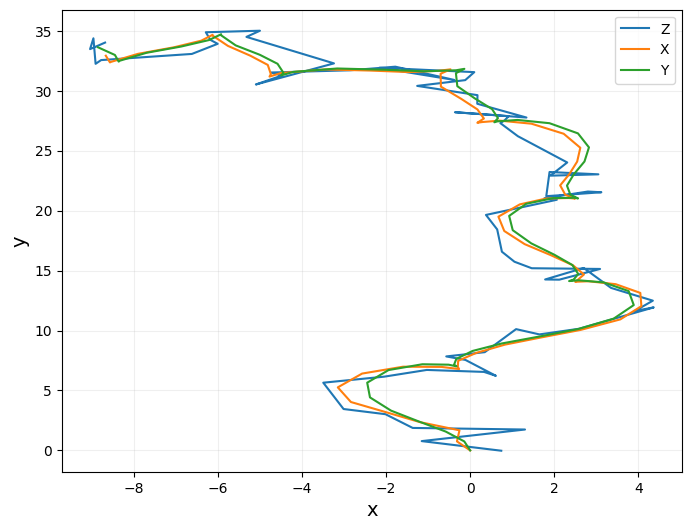

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(Z[0, :], Z[1, :], label="Z")
plt.plot(X[0, :], X[1, :], label="X")
plt.plot(Y[0, :], Y[1, :], label="Y")
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.grid(alpha=0.2)
plt.legend()
plt.show()

$X_{k}=(x_{k},y_{k},r_{k})$ - вектор-столбец

$X_{k+1}=f(X_{k})$

$f(X_{k}):$

$x[k+1]=x[k]+Ts_{t}[k]cos(r[k])-\frac{1}{2}T^{2}s_{t}[k]s_{r}[k]sin(r[k])$

$y[k+1]=y[k]+Ts_{t}[k]sin(r[k])+\frac{1}{2}T^{2}s_{t}[k]s_{r}[k]cos(r[k])$

$r[k+1]=r[k]+Ts_{r}[k]$

$F_{X}:$

$\frac{df_{1}(X_{k})}{dx}=1$;
$\frac{df_{1}(X_{k})}{dy}=0$;
$\frac{df_{1}(X_{k})}{dr}=-Ts_{t}sin(r[k])-\frac{1}{2}T^{2}s_{t}[k]s_{r}[k]cos(r[k])$;

$\frac{df_{2}(X_{k})}{dx}=0$;
$\frac{df_{2}(X_{k})}{dy}=1$;
$\frac{df_{2}(X_{k})}{dr}=Ts_{t}[k]cos(r[k])-\frac{1}{2}T^{2}s_{t}[k]s_{r}[k]sin(r[k])$;

$\frac{df_{3}(X_{k})}{dx}=0$;
$\frac{df_{3}(X_{k})}{dy}=0$;
$\frac{df_{3}(X_{k})}{dr}=1$;

$h(X_{k}):$

$h(x[k])=x[k]$

$h(y[k])=y[k]$

$h(r[k])=r[k]$

$H_{X}:$

$\frac{dh_{1}(X_{k})}{dx}=1$;
$\frac{dh_{1}(X_{k})}{dy}=0$;
$\frac{dh_{1}(X_{k})}{dr}=0$;

$\frac{dh_{2}(X_{k})}{dx}=0$;
$\frac{dh_{2}(X_{k})}{dy}=1$;
$\frac{dh_{2}(X_{k})}{dr}=0$;

$\frac{dh_{3}(X_{k})}{dx}=0$;
$\frac{dh_{3}(X_{k})}{dy}=0$;
$\frac{dh_{3}(X_{k})}{dr}=1$;

$W=(w_{x},w_{y},w_{r})$ - вектор-столбец

$R:$

$(D_{wx} \space 0 \space 0)$

$(0 \space D_{wy} \space 0)$

$(0 \space 0 \space D_{wr})$

# СОСТОЯНИЕ ОБЪЕКТА (вектор-столбец)
# x, y - координаты положения объекта на плоскости
# r - угол поворота (ориентация объекта), радианы
X_k = (x_k, y_k, r_k)  # вектор-столбец состояния в момент времени k

# МОДЕЛЬ ДВИЖЕНИЯ (нелинейная функция перехода состояния)
X_{k+1} = f(X_k)  # прогноз состояния на следующий шаг

# ПАРАМЕТРЫ МОДЕЛИ
# T - период дискретизации, шаг по времени
# s_t[k] - заданная линейная скорость (управление)
# s_r[k] - заданная угловая скорость (управление)

f(X_k):  # функция перехода состояния (модель движения)
    # Координата x: линейное движение + поправка от поворота
    x[k+1] = x[k] + T * s_t[k] * cos(r[k]) - 0.5 * T**2 * s_t[k] * s_r[k] * sin(r[k])
    
    # Координата y: линейное движение + поправка от поворота  
    y[k+1] = y[k] + T * s_t[k] * sin(r[k]) + 0.5 * T**2 * s_t[k] * s_r[k] * cos(r[k])
    
    # Угол поворота: интегрирование угловой скорости
    r[k+1] = r[k] + T * s_r[k]

# МАТРИЦА ЯКОБИ ДЛЯ ФУНКЦИИ ПЕРЕХОДА (линеаризация модели движения)
F_X:  # матрица частных производных df/dX
    
    # Производные для x[k+1]
    df1/dx = 1  # по x
    df1/dy = 0  # по y (не зависит)
    df1/dr = -T * s_t * sin(r[k]) - 0.5 * T**2 * s_t[k] * s_r[k] * cos(r[k])  # по углу
    
    # Производные для y[k+1]  
    df2/dx = 0  # по x (не зависит)
    df2/dy = 1  # по y
    df2/dr = T * s_t[k] * cos(r[k]) - 0.5 * T**2 * s_t[k] * s_r[k] * sin(r[k])  # по углу
    
    # Производные для r[k+1]
    df3/dx = 0  # по x (не зависит)
    df3/dy = 0  # по y (не зависит)
    df3/dr = 1  # по углу

# МОДЕЛЬ ИЗМЕРЕНИЙ (наблюдаемые величины)
h(X_k):  # функция измерений (что мы непосредственно наблюдаем)
    h(x[k]) = x[k]  # наблюдаем координату x
    h(y[k]) = y[k]  # наблюдаем координату y
    h(r[k]) = r[k]  # наблюдаем угол поворота

# МАТРИЦА ЯКОБИ ДЛЯ ФУНКЦИИ ИЗМЕРЕНИЙ
H_X:  # матрица частных производных dh/dX
    
    # Производные для измерения x
    dh1/dx = 1  # по x
    dh1/dy = 0  # по y (не зависит)
    dh1/dr = 0  # по углу (не зависит)
    
    # Производные для измерения y
    dh2/dx = 0  # по x (не зависит)
    dh2/dy = 1  # по y
    dh2/dr = 0  # по углу (не зависит)
    
    # Производные для измерения r
    dh3/dx = 0  # по x (не зависит)
    dh3/dy = 0  # по y (не зависит)
    dh3/dr = 1  # по углу

# ШУМ ПРОЦЕССА (вектор-столбец)
# w_x, w_y - возмущения по координатам
# w_r - возмущение по углу
W = (w_x, w_y, w_r)  # вектор-столбец шума процесса

# КОВАРИАЦИОННАЯ МАТРИЦА ШУМА ИЗМЕРЕНИЙ
R:  # матрица 3x3, диагональная (предполагаем независимость шумов)
    [D_wx   0     0   ]  # дисперсия шума по x
    [ 0   D_wy   0   ]  # дисперсия шума по y
    [ 0     0   D_wr ]  # дисперсия шума по углу

# D_wx, D_wy, D_wr - дисперсии соответствующих шумов измерений

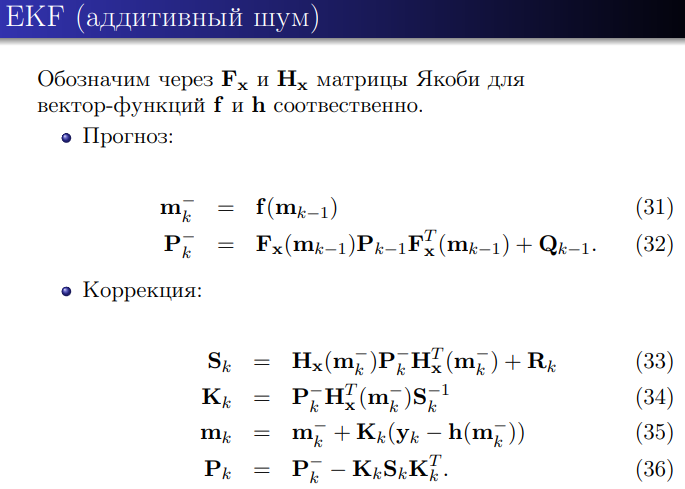

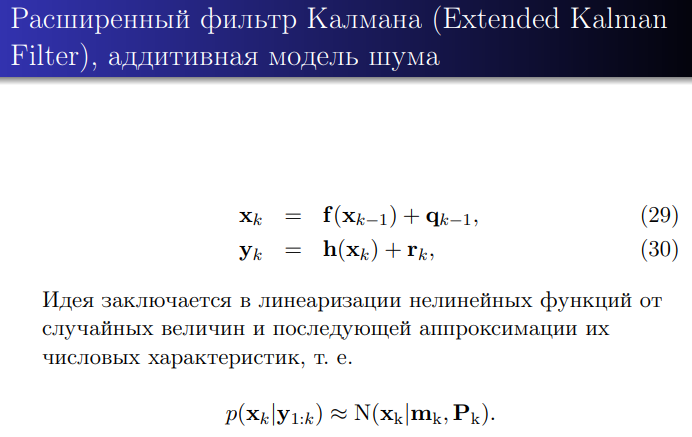

# 2 задание

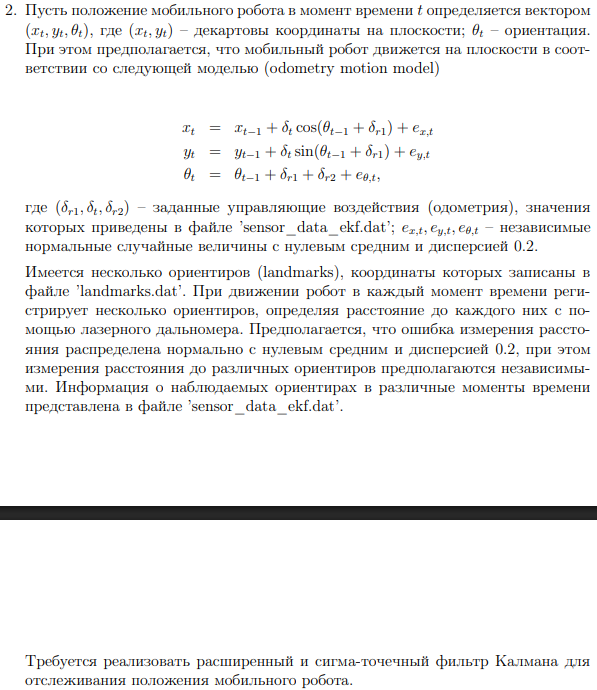

Загружено 9 ориентиров
Загружено 1543 записей данных
Первые несколько записей:
  1: ('odom', array([0.10137369, 0.09962523, 0.00086224]))
  2: ('sensor', 1, 2.29725290252)
  3: ('sensor', 2, 4.01825728983)
  4: ('odom', array([ 0.10182319,  0.09972489, -0.00020665]))
  5: ('sensor', 1, 1.96846687533)

Запуск EKF...
EKF завершен. Получено 1544 точек траектории.

Запуск UKF...
UKF завершен. Получено 1544 точек траектории.


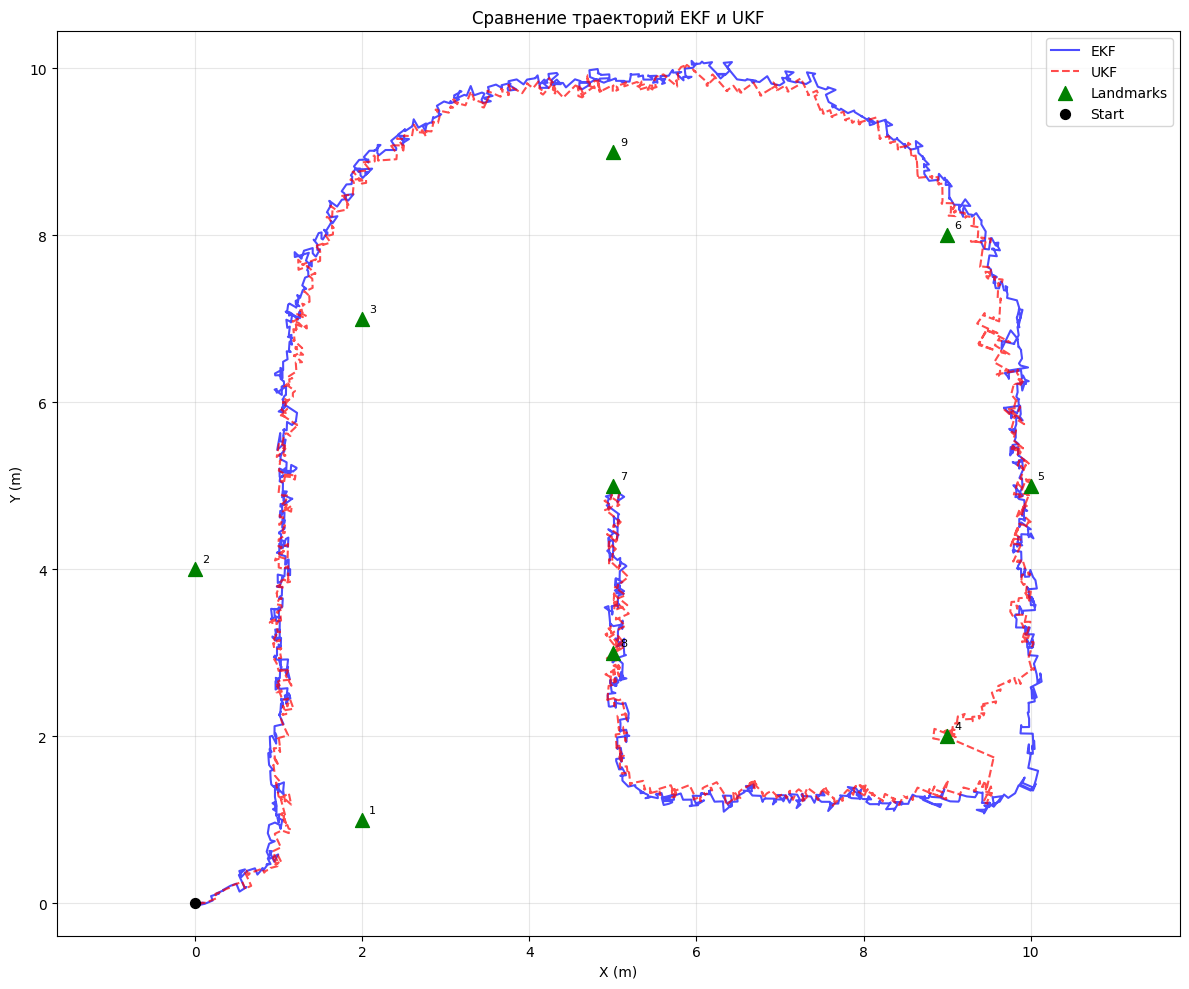

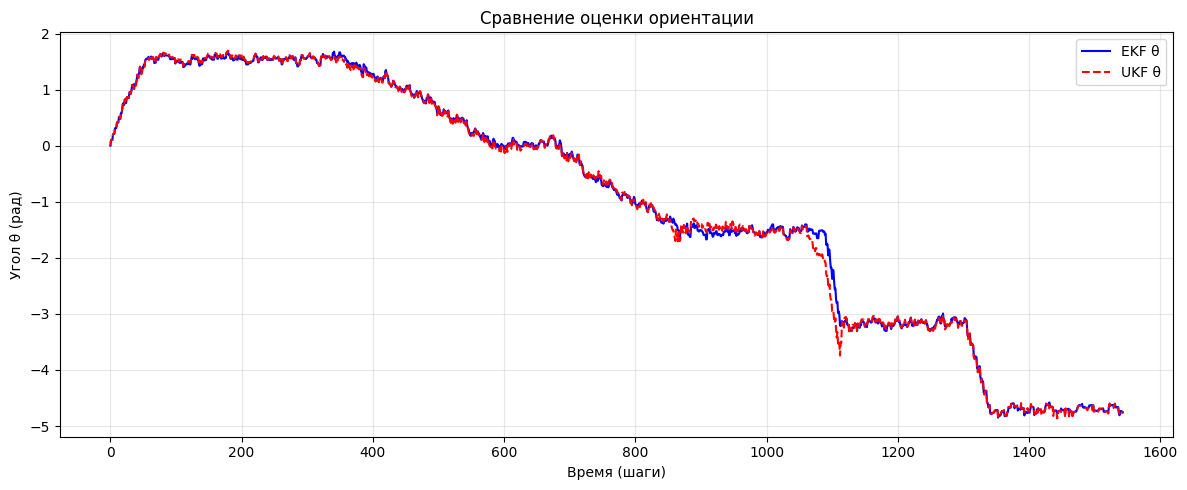

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Загрузка данных ---
def load_data(sensor_file, landmarks_file):
    """Загружает данные из файлов."""
    landmarks = {}
    with open(landmarks_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                lm_id = int(parts[0])
                lm_x = float(parts[1])
                lm_y = float(parts[2])
                landmarks[lm_id] = np.array([lm_x, lm_y])

    data_sequence = []
    with open(sensor_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cmd = parts[0]
            if cmd == 'ODOMETRY':
                u = np.array([float(parts[1]), float(parts[2]), float(parts[3])])
                data_sequence.append(('odom', u))
            elif cmd == 'SENSOR':
                lm_id = int(parts[1])
                distance = float(parts[2])
                data_sequence.append(('sensor', lm_id, distance))
    return landmarks, data_sequence

# --- Модели ---
def motion_model(x, u):
    """Модель движения (перехода состояния). x = [x, y, theta], u = [delta_r1, delta_t, delta_r2]"""
    x_prev, y_prev, theta_prev = x
    
    delta_r1, delta_t, delta_r2 = u
    
    theta_new = theta_prev + delta_r1 + delta_r2
    x_new = x_prev + delta_t * np.cos(theta_prev + delta_r1)
    y_new = y_prev + delta_t * np.sin(theta_prev + delta_r1)
    return np.array([x_new, y_new, theta_new])

def observation_model(x, landmark):
    """Модель наблюдения (расстояние до ориентира)."""
    lm_x, lm_y = landmark
    return np.linalg.norm(x[:2] - [lm_x, lm_y])

# --- Якобианы для EKF ---
def jacobian_motion(x, u):
    """Вычисляет матрицу Якоби G для модели движения по состоянию."""
    theta_prev = x[2]
    delta_t = u[1]
    delta_r1 = u[0]

    G = np.eye(3)
    G[0, 2] = -delta_t * np.sin(theta_prev + delta_r1)
    G[1, 2] = delta_t * np.cos(theta_prev + delta_r1)
    return G

def jacobian_observation(x, landmark):
    """Вычисляет матрицу Якоби H для модели наблюдения по состоянию."""
    lm_x, lm_y = landmark
    dx = x[0] - lm_x
    dy = x[1] - lm_y
    dist = np.linalg.norm([dx, dy])

    if dist < 1e-12:
        H = np.zeros((1, 3))
    else:
        H = np.array([[dx / dist, dy / dist, 0.0]])
    return H

# --- Вспомогательные функции для UKF ---
def generate_sigma_points(m, P, alpha, beta, kappa):
    """Генерирует сигма-точки и веса для UKF."""
    n = len(m)
    lamb = alpha**2 * (n + kappa) - n
    # Вычисляем sqrt((n+lamb)*P)
    try:
        sqrt_term = np.linalg.cholesky((n + lamb) * P)
    except np.linalg.LinAlgError:
        # Если матрица не положительно определена, добавляем небольшую регуляризацию
        P_reg = P + 1e-9 * np.eye(n)
        sqrt_term = np.linalg.cholesky((n + lamb) * P_reg)

    # Сигма-точки
    sigma_points = np.zeros((2*n + 1, n))
    sigma_points[0] = m
    for i in range(n):
        sigma_points[i+1] = m + sqrt_term[:, i]
        sigma_points[i+1+n] = m - sqrt_term[:, i]

    # Веса
    Wm = np.zeros(2*n + 1)
    Wc = np.zeros(2*n + 1)
    Wm[0] = lamb / (n + lamb)
    Wc[0] = Wm[0] + (1 - alpha**2 + beta)
    for i in range(1, 2*n + 1):
        Wm[i] = 1 / (2*(n + lamb))
        Wc[i] = Wm[i]

    return sigma_points, Wm, Wc

def unscented_transform(sigma_points, Wm, Wc, noise_cov=None, func=None, *args, **kwargs):
    """
    Применяет unscented transform.
    Если func передана, применяет её к сигма-точкам.
    """
    n_sigma, n_dim = sigma_points.shape
    if func is not None:
        transformed_points = np.array([func(sp, *args, **kwargs) for sp in sigma_points])
        # Убеждаемся, что transformed_points имеет правильную форму
        if len(transformed_points.shape) == 1:
            transformed_points = transformed_points.reshape(-1, 1)
    else:
        transformed_points = sigma_points

    # Вычисляем среднее
    mean = np.sum(Wm[:, np.newaxis] * transformed_points, axis=0)

    # Вычисляем ковариацию
    cov = np.zeros((mean.shape[0], mean.shape[0]))
    for i in range(n_sigma):
        diff = (transformed_points[i] - mean).reshape(-1, 1)
        cov += Wc[i] * (diff @ diff.T)

    if noise_cov is not None:
        cov += noise_cov

    return mean, cov, transformed_points

# --- Реализация EKF ---
def run_ekf(landmarks, data_sequence):
    """Запускает EKF на последовательности данных."""
    # Начальное состояние и ковариация
    mu = np.array([0.0, 0.0, 0.0])
    Sigma = np.eye(3) * 0.1  # Небольшая начальная неуверенность

    # Шумы
    R = np.diag([0.2, 0.2, 0.2])  # Шум процесса (дисперсия 0.2)
    Q = np.array([[0.2]])         # Шум измерения (дисперсия 0.2)

    trajectory = [mu.copy()]
    last_odom_time = 0

    for item in data_sequence:
        if item[0] == 'odom':
            # --- Шаг предсказания EKF ---
            u = item[1]
            G = jacobian_motion(mu, u)
            mu = motion_model(mu, u)
            Sigma = G @ Sigma @ G.T + R
            last_odom_time += 1

        elif item[0] == 'sensor':
            # --- Шаг коррекции EKF ---
            lm_id, z = item[1], item[2]
            landmark = landmarks[lm_id]

            # Ожидаемое измерение и Якобиан
            z_hat = observation_model(mu, landmark)
            H = jacobian_observation(mu, landmark)

            # Инновация и её ковариация
            y = np.array([z - z_hat]).reshape(1, 1)
            S = H @ Sigma @ H.T + Q

            # Проверка на вырожденность S
            if np.linalg.det(S) < 1e-12:
                continue

            # Коэффициент Калмана
            K = Sigma @ H.T @ np.linalg.inv(S)

            # Обновление состояния (исправлено: правильно обрабатываем размерности)
            mu = mu + (K @ y).flatten()
            Sigma = (np.eye(3) - K @ H) @ Sigma

        trajectory.append(mu.copy())

    return np.array(trajectory)

# --- Реализация UKF ---
def run_ukf(landmarks, data_sequence):
    """Запускает UKF на последовательности данных."""
    # Параметры UKF
    alpha = 1e-3
    beta = 2
    kappa = 0

    # Начальное состояние и ковариация
    mu = np.array([0.0, 0.0, 0.0])
    Sigma = np.eye(3) * 0.1

    # Шумы
    R = np.diag([0.2, 0.2, 0.2])
    Q = np.array([[0.2]])

    trajectory = [mu.copy()]

    for item in data_sequence:
        if item[0] == 'odom':
            # --- Шаг предсказания UKF ---
            u = item[1]

            # Генерация сигма-точек для текущего состояния
            sigma_points, Wm, Wc = generate_sigma_points(mu, Sigma, alpha, beta, kappa)

            # Пропуск точек через функцию движения и применение UT
            mu_pred, Sigma_pred, _ = unscented_transform(sigma_points, Wm, Wc, R, motion_model, u)
            mu, Sigma = mu_pred, Sigma_pred

        elif item[0] == 'sensor':
            # --- Шаг коррекции UKF ---
            lm_id, z = item[1], item[2]
            landmark = landmarks[lm_id]

            # Генерация сигма-точек для предсказанного состояния
            sigma_points, Wm, Wc = generate_sigma_points(mu, Sigma, alpha, beta, kappa)

            # Применяем функцию наблюдения к сигма-точкам для получения предсказанных измерений
            def obs_func_wrapper(state):
                return np.array([observation_model(state, landmark)])

            z_pred_mean, S, Z_sigma = unscented_transform(
                sigma_points, Wm, Wc, Q, obs_func_wrapper
            )

            # Вычисляем кросс-ковариацию между состоянием и измерением
            Pxz = np.zeros((3, 1))
            for i in range(len(sigma_points)):
                diff_x = (sigma_points[i] - mu).reshape(-1, 1)
                diff_z = (Z_sigma[i] - z_pred_mean).reshape(-1, 1)
                Pxz += Wc[i] * (diff_x @ diff_z.T)

            # Коэффициент Калмана
            K = Pxz @ np.linalg.inv(S)

            # Инновация
            y = np.array([z - z_pred_mean]).reshape(1, 1)

            # Обновление состояния
            mu = mu + (K @ y).flatten()
            Sigma = Sigma - K @ S @ K.T

        trajectory.append(mu.copy())

    return np.array(trajectory)

# --- Основная часть ---
if __name__ == "__main__":
    landmarks_file = 'data_files/landmarks.dat'
    sensor_file = 'data_files/sensor_data_ekf.dat'

    # Загрузка данных
    landmarks, data_sequence = load_data(sensor_file, landmarks_file)
    
    print(f"Загружено {len(landmarks)} ориентиров")
    print(f"Загружено {len(data_sequence)} записей данных")
    print("Первые несколько записей:")
    for i, item in enumerate(data_sequence[:5]):
        print(f"  {i+1}: {item}")

    # Запуск фильтров
    print("\nЗапуск EKF...")
    ekf_traj = run_ekf(landmarks, data_sequence)
    print(f"EKF завершен. Получено {len(ekf_traj)} точек траектории.")

    print("\nЗапуск UKF...")
    ukf_traj = run_ukf(landmarks, data_sequence)
    print(f"UKF завершен. Получено {len(ukf_traj)} точек траектории.")

    # Визуализация
    plt.figure(figsize=(12, 10))

    # Траектории
    plt.plot(ekf_traj[:, 0], ekf_traj[:, 1], 'b-', label='EKF', linewidth=1.5, alpha=0.7)
    plt.plot(ukf_traj[:, 0], ukf_traj[:, 1], 'r--', label='UKF', linewidth=1.5, alpha=0.7)

    # Ориентиры
    lm_coords = np.array(list(landmarks.values()))
    lm_ids = list(landmarks.keys())
    plt.scatter(lm_coords[:, 0], lm_coords[:, 1], c='green', marker='^', s=100, label='Landmarks', zorder=5)
    
    # Добавляем подписи к ориентирам
    for i, lm_id in enumerate(lm_ids):
        plt.annotate(str(lm_id), (lm_coords[i, 0], lm_coords[i, 1]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

    # Начальная точка
    plt.scatter([0], [0], c='black', marker='o', s=50, label='Start', zorder=5)

    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.title('Сравнение траекторий EKF и UKF')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    # Дополнительно: построим графики изменения угла theta
    plt.figure(figsize=(12, 5))
    time_axis = np.arange(len(ekf_traj))
    plt.plot(time_axis, ekf_traj[:, 2], 'b-', label='EKF θ', linewidth=1.5)
    plt.plot(time_axis, ukf_traj[:, 2], 'r--', label='UKF θ', linewidth=1.5)
    plt.xlabel('Время (шаги)')
    plt.ylabel('Угол θ (рад)')
    plt.title('Сравнение оценки ориентации')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 3 задание

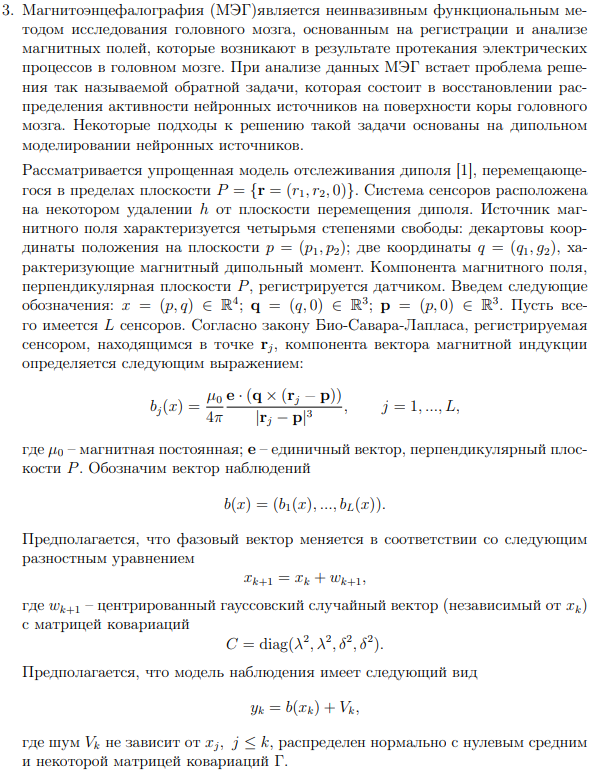
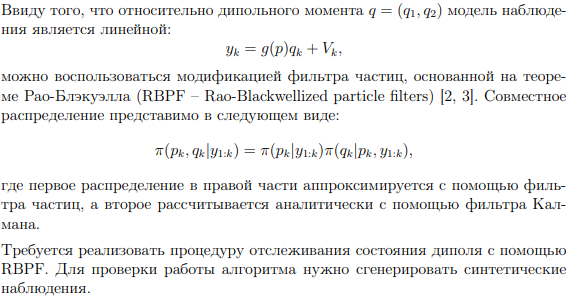

Форма sensor_positions: (100, 3)
Первые 5 сенсоров:
[[2.         2.         3.        ]
 [3.22222222 2.         3.        ]
 [4.44444444 2.         3.        ]
 [5.66666667 2.         3.        ]
 [6.88888889 2.         3.        ]]
Максимальный сигнал: 0.1366
Форма данных измерений: (30, 100)

Запуск исправленного RBPF...
Шаг 0: ESS=32.3, p_est=(10.81, 7.48), q_est=(3.68, 0.80)
Шаг 5: ESS=19.6, p_est=(8.75, 10.59), q_est=(2.70, 2.20)
Шаг 10: ESS=235.8, p_est=(7.44, 11.55), q_est=(1.30, 0.53)
Шаг 15: ESS=232.2, p_est=(4.02, 7.65), q_est=(2.32, 0.76)
Шаг 20: ESS=187.7, p_est=(4.95, 4.13), q_est=(2.14, 1.74)
Шаг 25: ESS=11.9, p_est=(9.67, 3.02), q_est=(1.39, 1.25)


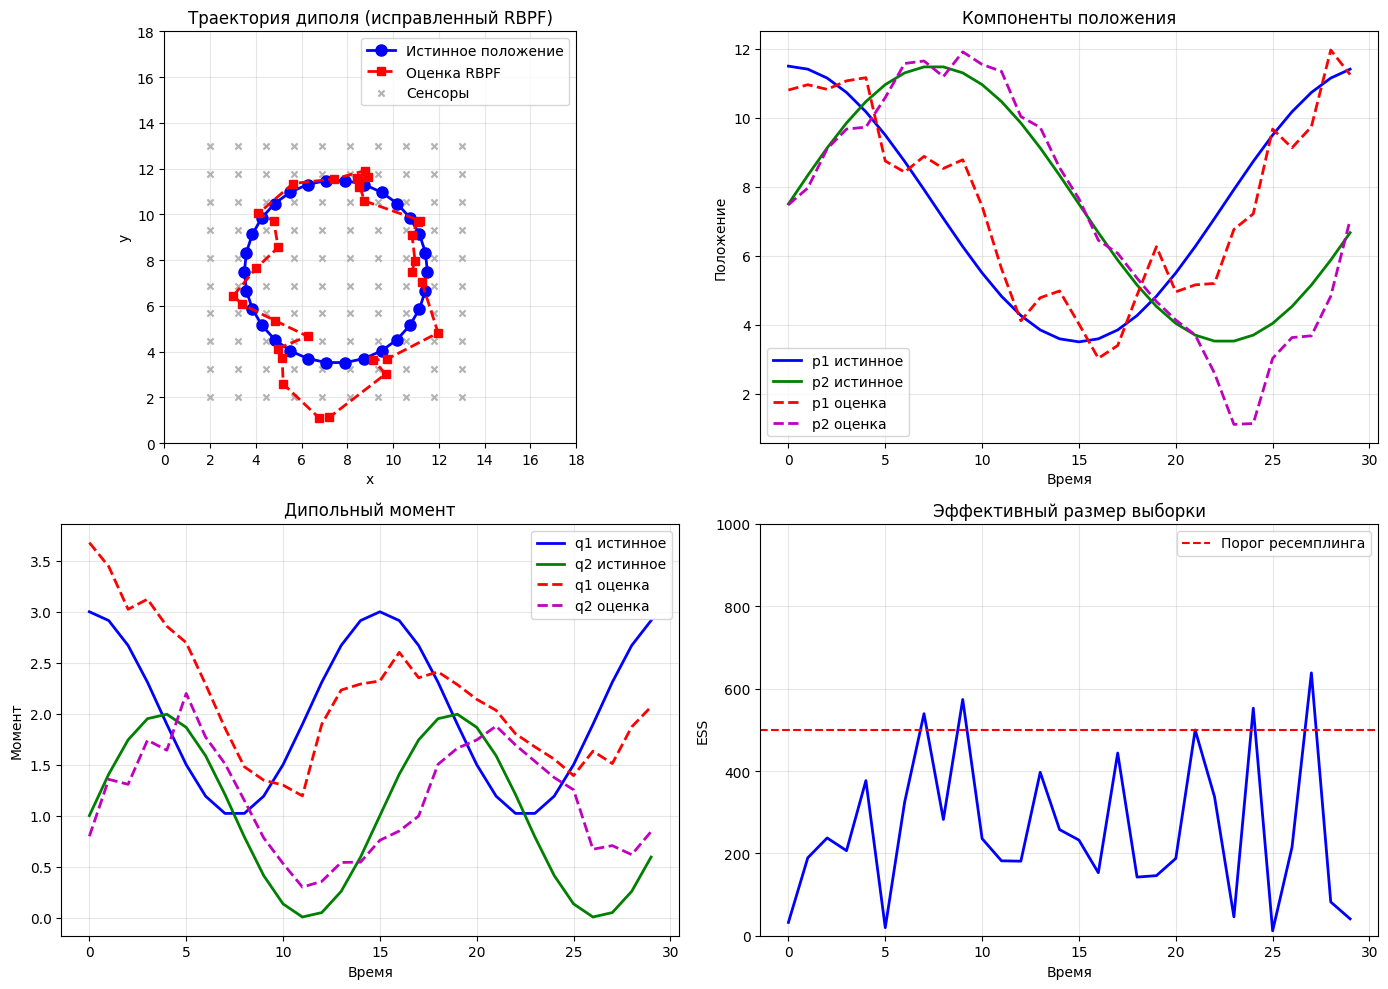


РЕЗУЛЬТАТЫ:
MSE положения: 0.9263
MSE момента: 0.3197
Средний ESS: 258.8
Минимальный ESS: 11.9


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve, inv

# ------------------------------------------------------------
# Параметры задачи
# ------------------------------------------------------------
np.random.seed(42)

L = 100  # число сенсоров (10x10 сетка)
N = 1000  # число частиц (уменьшим для скорости, но можно увеличить)
K = 30  # число временных шагов

mu0_over_4pi = 1.0  # упрощение

# Параметры модели (из статьи)
lambda_ = 1.0  # шаг положения
delta = 0.25   # шаг момента
h = 3.0        # расстояние до сенсоров

# Шум измерений (80% от макс. сигнала как в статье)
sigma_noise = 0.8

# ------------------------------------------------------------
# Сенсоры: квадратная сетка 10x10
# ------------------------------------------------------------
x = np.linspace(2, 13, 10)
y = np.linspace(2, 13, 10)
X, Y = np.meshgrid(x, y)

# ИСПРАВЛЕНО: Правильное формирование массива сенсоров
sensor_positions = np.zeros((L, 3))
sensor_positions[:, 0] = X.ravel()  # x координаты
sensor_positions[:, 1] = Y.ravel()  # y координаты
sensor_positions[:, 2] = h           # z координаты (одинаковая для всех)

print(f"Форма sensor_positions: {sensor_positions.shape}")
print(f"Первые 5 сенсоров:\n{sensor_positions[:5]}")

def G_matrix(p, sensor_positions, mu0_over_4pi=1.0):
    """
    Матрица G размером (L, 2)
    b = G @ q, где G[j,:] = [ (y_j - p2)/r^3,  -(x_j - p1)/r^3 ] * mu0/(4π)
    """
    p = np.asarray(p).flatten()
    if len(p) == 2:
        p_full = np.array([p[0], p[1], 0.0])
    else:
        p_full = p
    
    # Вектор от диполя до сенсора
    diff = sensor_positions - p_full  # (L, 3)
    r = np.linalg.norm(diff, axis=1)
    r3 = r**3
    
    # Избегаем деления на ноль
    r3 = np.maximum(r3, 1e-10)
    
    # Формируем матрицу G
    G = np.zeros((len(sensor_positions), 2))
    G[:, 0] = diff[:, 1] / r3   # (y_j - p2) / r^3
    G[:, 1] = -diff[:, 0] / r3  # -(x_j - p1) / r^3
    
    return mu0_over_4pi * G

# ------------------------------------------------------------
# Генерация синтетических данных
# ------------------------------------------------------------
t = np.linspace(0, 2*np.pi, K, endpoint=False)
p_true = np.array([7.5 + 4*np.cos(t), 7.5 + 4*np.sin(t)]).T  # (K,2)
q_true = np.array([2.0 + 1.0*np.cos(2*t), 1.0 + 1.0*np.sin(2*t)]).T  # (K,2)

# Оценим максимальный сигнал для настройки шума
max_signal = 0
for k in range(K):
    Gk = G_matrix(p_true[k], sensor_positions, mu0_over_4pi)
    signal = Gk @ q_true[k]
    max_signal = max(max_signal, np.max(np.abs(signal)))

print(f"Максимальный сигнал: {max_signal:.4f}")

Gamma = (sigma_noise * max_signal)**2 * np.eye(L)
# Добавим небольшую регуляризацию для численной устойчивости
Gamma_reg = Gamma + 1e-6 * np.eye(L)

# Генерация измерений
y_meas = []
for k in range(K):
    Gk = G_matrix(p_true[k], sensor_positions, mu0_over_4pi)
    y_clean = Gk @ q_true[k]
    noise = np.random.multivariate_normal(np.zeros(L), Gamma)
    y_meas.append(y_clean + noise)
y_meas = np.array(y_meas)

print(f"Форма данных измерений: {y_meas.shape}")

# ------------------------------------------------------------
# ИСПРАВЛЕННАЯ реализация RBPF
# ------------------------------------------------------------
class FixedRBPF:
    def __init__(self, N, lambda_, delta, Gamma, sensor_positions):
        self.N = N
        self.lambda_ = lambda_
        self.delta = delta
        self.Gamma = Gamma
        self.Gamma_inv = inv(Gamma + 1e-6 * np.eye(len(Gamma)))
        self.sensor_positions = sensor_positions
        
        # Инициализация частиц
        # Положение: равномерно по области
        self.p = np.random.uniform(low=[2, 2], high=[13, 13], size=(N, 2))
        
        # Для момента: используем широкое априорное распределение
        self.q_mean = np.zeros((N, 2))
        # Инициализируем ковариацию как массив матриц
        self.q_cov = np.array([100 * np.eye(2) for _ in range(N)])  # Большая неопределенность
        
        # Веса равномерные
        self.weights = np.ones(N) / N
        
        # Для отладки
        self.ess_history = []
        
    def predict_and_update(self, y):
        """
        Один шаг фильтра с правильным обновлением
        """
        N = self.N
        new_p = np.zeros_like(self.p)
        new_q_mean = np.zeros_like(self.q_mean)
        new_q_cov = np.zeros_like(self.q_cov)
        log_weights = np.zeros(N)
        
        for i in range(N):
            # 1. Предсказание положения (случайное блуждание)
            new_p[i] = self.p[i] + np.random.normal(0, self.lambda_, size=2)
            
            # 2. Предсказание момента
            # Момент тоже совершает случайное блуждание: q_k = q_{k-1} + w_q
            q_mean_pred = self.q_mean[i].copy()
            q_cov_pred = self.q_cov[i] + self.delta**2 * np.eye(2)
            
            # 3. Вычисляем матрицу наблюдений для предсказанного положения
            G = G_matrix(new_p[i], self.sensor_positions)
            
            # 4. Обновление по Калману
            # Предсказание измерения
            y_pred = G @ q_mean_pred
            
            # Инновация
            innovation = y - y_pred
            
            # Ковариация инновации
            S = G @ q_cov_pred @ G.T + self.Gamma
            
            # Добавляем регуляризацию для численной устойчивости
            S = S + 1e-6 * np.eye(len(S))
            
            # Вычисляем коэффициент Калмана
            try:
                # Решаем систему S @ K.T = (G @ q_cov_pred).T
                K = np.linalg.solve(S.T, (q_cov_pred @ G.T).T).T
                
                # Обновляем среднее и ковариацию
                new_q_mean[i] = q_mean_pred + K @ innovation
                new_q_cov[i] = q_cov_pred - K @ G @ q_cov_pred
                
                # Логарифм правдоподобия для веса
                sign, logdet = np.linalg.slogdet(S)
                if sign <= 0:
                    log_lik = -1e10
                else:
                    log_lik = -0.5 * (innovation @ np.linalg.solve(S, innovation) + 
                                      logdet + len(y) * np.log(2*np.pi))
                
            except np.linalg.LinAlgError:
                # Если матрица сингулярна, используем псевдообратную
                S_pinv = np.linalg.pinv(S)
                K = q_cov_pred @ G.T @ S_pinv
                new_q_mean[i] = q_mean_pred + K @ innovation
                new_q_cov[i] = q_cov_pred - K @ G @ q_cov_pred
                
                # Упрощенное правдоподобие
                innovation_scaled = innovation / np.sqrt(np.diag(self.Gamma))
                log_lik = -0.5 * np.sum(innovation_scaled**2)
            
            # Сохраняем логарифм веса
            log_weights[i] = np.log(self.weights[i] + 1e-300) + log_lik
        
        # Нормализация весов в логарифмической области
        max_log = np.max(log_weights)
        log_weights -= max_log
        weights = np.exp(log_weights)
        weights_sum = np.sum(weights)
        
        if weights_sum > 0:
            weights /= weights_sum
        else:
            # Если все веса нулевые, восстанавливаем равномерные
            weights = np.ones(N) / N
            print(f"Warning: Все веса нулевые на шаге {len(self.ess_history)}")
        
        self.weights = weights
        self.p = new_p
        self.q_mean = new_q_mean
        self.q_cov = new_q_cov
        
        # Вычисляем эффективный размер выборки
        ess = 1.0 / np.sum(weights**2)
        self.ess_history.append(ess)
        
        return weights
    
    def resample(self):
        """
        Систематический ресемплинг
        """
        N = self.N
        weights = self.weights
        
        # Систематический ресемплинг
        positions = (np.random.random() + np.arange(N)) / N
        indexes = np.zeros(N, dtype=int)
        cumulative_sum = np.cumsum(weights)
        i, j = 0, 0
        while i < N:
            if positions[i] < cumulative_sum[j]:
                indexes[i] = j
                i += 1
            else:
                j += 1
        
        # Обновляем частицы
        self.p = self.p[indexes]
        self.q_mean = self.q_mean[indexes]
        self.q_cov = self.q_cov[indexes]
        self.weights = np.ones(N) / N
    
    def estimate(self):
        """
        Оценка текущего состояния (взвешенное среднее)
        """
        p_est = np.average(self.p, axis=0, weights=self.weights)
        q_est = np.average(self.q_mean, axis=0, weights=self.weights)
        return p_est, q_est
    
    def get_state(self):
        """
        Возвращает текущее состояние для отладки
        """
        return self.p, self.q_mean, self.q_cov, self.weights

# ------------------------------------------------------------
# Запуск исправленного фильтра
# ------------------------------------------------------------
print("\nЗапуск исправленного RBPF...")
pf_fixed = FixedRBPF(N, lambda_, delta, Gamma_reg, sensor_positions)

p_estimates_fixed = []
q_estimates_fixed = []

for k in range(K):
    # Шаг фильтрации
    weights = pf_fixed.predict_and_update(y_meas[k])
    
    # Ресемплинг при необходимости
    ess = pf_fixed.ess_history[-1]
    if ess < N / 2:
        pf_fixed.resample()
        #print(f"Шаг {k}: ресемплинг (ESS={ess:.1f})")
    
    # Сохраняем оценку
    p_est, q_est = pf_fixed.estimate()
    p_estimates_fixed.append(p_est)
    q_estimates_fixed.append(q_est)
    
    if k % 5 == 0:
        print(f"Шаг {k}: ESS={ess:.1f}, p_est=({p_est[0]:.2f}, {p_est[1]:.2f}), "
              f"q_est=({q_est[0]:.2f}, {q_est[1]:.2f})")

p_estimates_fixed = np.array(p_estimates_fixed)
q_estimates_fixed = np.array(q_estimates_fixed)

# ------------------------------------------------------------
# Визуализация результатов
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Траектория
ax = axes[0, 0]
ax.plot(p_true[:, 0], p_true[:, 1], 'b-o', linewidth=2, markersize=8, label='Истинное положение')
ax.plot(p_estimates_fixed[:, 0], p_estimates_fixed[:, 1], 'r--s', linewidth=2, markersize=6, label='Оценка RBPF')
ax.scatter(sensor_positions[:, 0], sensor_positions[:, 1], 
           c='k', marker='x', s=20, alpha=0.3, label='Сенсоры')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Траектория диполя (исправленный RBPF)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 18])
ax.set_ylim([0, 18])
ax.set_aspect('equal')

# Компоненты положения
ax = axes[0, 1]
ax.plot(p_true[:, 0], 'b-', linewidth=2, label='p1 истинное')
ax.plot(p_true[:, 1], 'g-', linewidth=2, label='p2 истинное')
ax.plot(p_estimates_fixed[:, 0], 'r--', linewidth=2, label='p1 оценка')
ax.plot(p_estimates_fixed[:, 1], 'm--', linewidth=2, label='p2 оценка')
ax.set_xlabel('Время')
ax.set_ylabel('Положение')
ax.set_title('Компоненты положения')
ax.legend()
ax.grid(True, alpha=0.3)

# Дипольный момент
ax = axes[1, 0]
ax.plot(q_true[:, 0], 'b-', linewidth=2, label='q1 истинное')
ax.plot(q_true[:, 1], 'g-', linewidth=2, label='q2 истинное')
ax.plot(q_estimates_fixed[:, 0], 'r--', linewidth=2, label='q1 оценка')
ax.plot(q_estimates_fixed[:, 1], 'm--', linewidth=2, label='q2 оценка')
ax.set_xlabel('Время')
ax.set_ylabel('Момент')
ax.set_title('Дипольный момент')
ax.legend()
ax.grid(True, alpha=0.3)

# Эффективный размер выборки
ax = axes[1, 1]
ax.plot(pf_fixed.ess_history, 'b-', linewidth=2)
ax.axhline(y=N/2, color='r', linestyle='--', label='Порог ресемплинга')
ax.set_xlabel('Время')
ax.set_ylabel('ESS')
ax.set_title('Эффективный размер выборки')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, N])

plt.tight_layout()
plt.savefig('rbpf_fixed_results.png', dpi=150)
plt.show()

# ------------------------------------------------------------
# Вывод статистики
# ------------------------------------------------------------
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ:")
print("="*50)

# MSE для RBPF
mse_p_rbpf = np.mean((p_estimates_fixed - p_true)**2)
mse_q_rbpf = np.mean((q_estimates_fixed - q_true)**2)

print(f"MSE положения: {mse_p_rbpf:.4f}")
print(f"MSE момента: {mse_q_rbpf:.4f}")
print(f"Средний ESS: {np.mean(pf_fixed.ess_history):.1f}")
print(f"Минимальный ESS: {np.min(pf_fixed.ess_history):.1f}")

# 4 задание

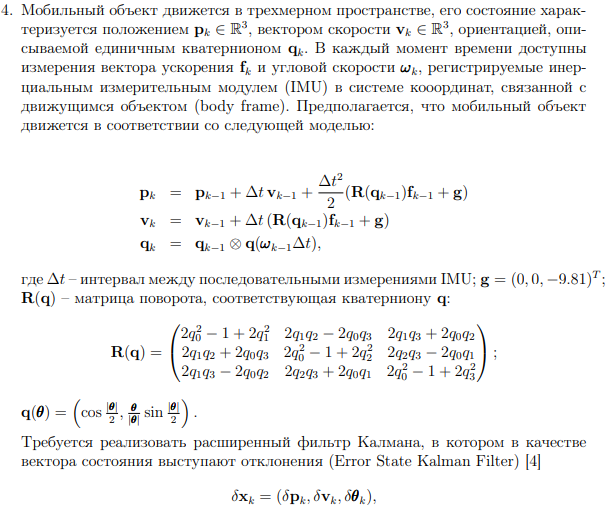
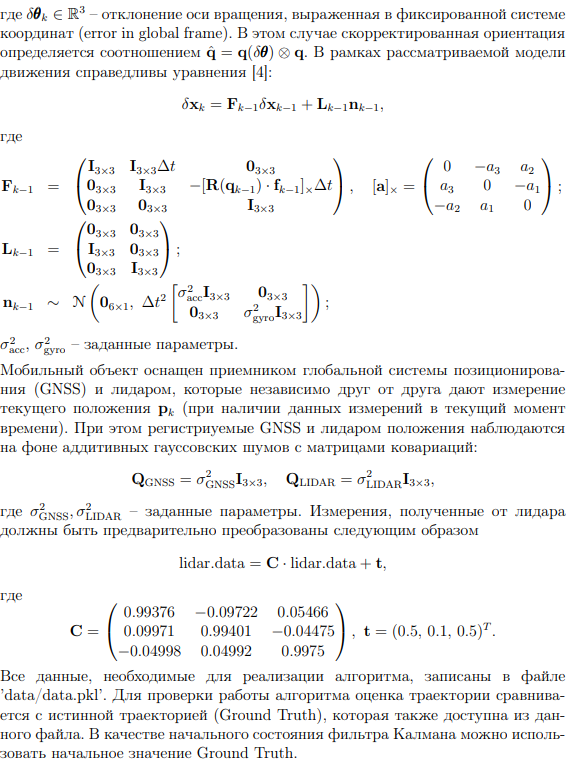

# 5 задание

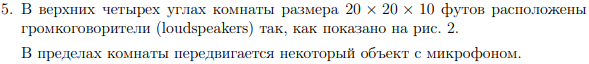
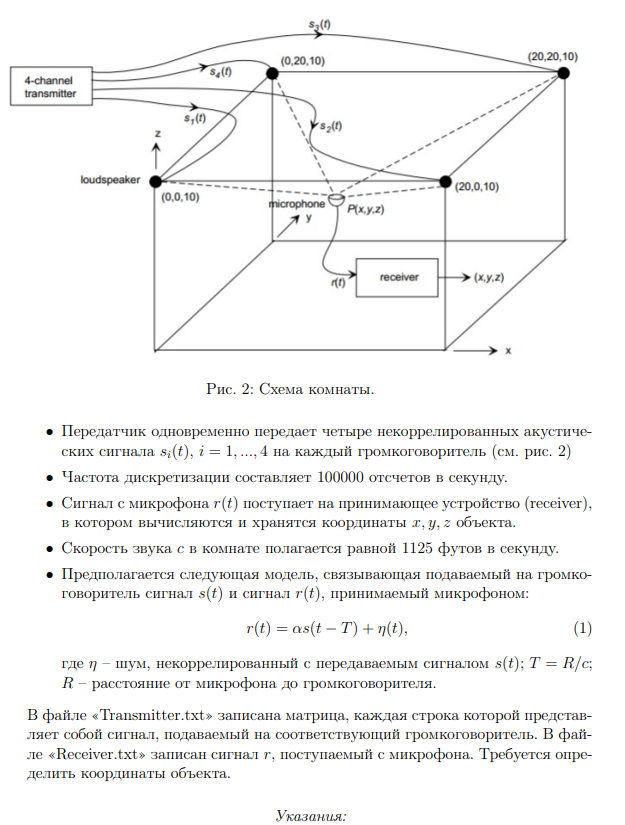
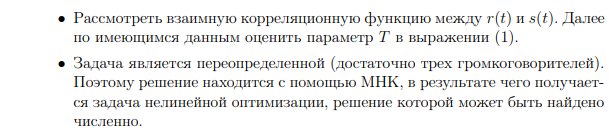

In [11]:
import numpy as np
from scipy.optimize import minimize

# Константы
SOUND_SPEED = 1125  # скорость звука (фут/с)
SAMPLE_RATE = 100000  # частота дискретизации (Гц)

# Позиции громкоговорителей (источников звука)
SPEAKER_POSITIONS = np.array([
    [0, 0, 10],
    [20, 0, 10],
    [20, 20, 10],
    [0, 20, 10]
])

def compute_time_delay(received_signal, reference_signal):
    """
    Вычисление временной задержки между сигналами
    с использованием взаимной корреляции
    """
    # Взаимная корреляция сигналов
    correlation = np.correlate(received_signal, reference_signal, mode='same')
    
    # Индекс максимальной корреляции = временной сдвиг
    peak_index = np.argmax(np.abs(correlation))
    
    # Преобразование индекса в секунды
    return peak_index / SAMPLE_RATE

def compute_distances_from_delays(delays):
    """
    Перевод временных задержек в расстояния
    """
    return [delay * SOUND_SPEED for delay in delays]

def residuals_squared(point, measured_distances):
    """
    Функция невязок для оптимизации методом наименьших квадратов
    point: предполагаемые координаты микрофона [x, y, z]
    measured_distances: измеренные расстояния до громкоговорителей
    """
    x, y, z = point
    errors = []
    
    for idx, (sx, sy, sz) in enumerate(SPEAKER_POSITIONS):
        # Евклидово расстояние от микрофона до громкоговорителя
        dx = x - sx
        dy = y - sy
        dz = z - sz
        calculated_distance = np.sqrt(dx*dx + dy*dy + dz*dz)
        
        # Разница между расчетным и измеренным расстоянием
        errors.append(calculated_distance - measured_distances[idx])
    
    return np.sum(np.square(errors))

def main():
    # Загрузка данных
    transmitter_signals = np.loadtxt("data_files/Transmitter.txt")  # сигналы с передатчиков (4xN)
    receiver_signal = np.loadtxt("data_files/Receiver.txt")        # сигнал с приемника (1xN)
    
    # Расчет временных задержек для всех громкоговорителей
    time_delays = [
        compute_time_delay(receiver_signal, transmitter_signals[i])
        for i in range(len(SPEAKER_POSITIONS))
    ]
    
    # Преобразование задержек в расстояния
    measured_ranges = compute_distances_from_delays(time_delays)
    
    # Начальное приближение для оптимизации
    initial_estimate = [10.0, 5.0, 5.0]
    
    # Минимизация методом L-BFGS-B
    optimization_result = minimize(
        residuals_squared,
        initial_estimate,
        args=(measured_ranges,),
        method='L-BFGS-B'
    )
    
    # Извлечение результата
    x_coord, y_coord, z_coord = optimization_result.x
    
    print(f"Локализация микрофона завершена")
    print(f"Координаты: X = {x_coord:.2f}, Y = {y_coord:.2f}, Z = {z_coord:.2f}")
    print(f"Невязка: {optimization_result.fun:.6f}")

if __name__ == "__main__":
    main()

Локализация микрофона завершена
Координаты: X = 7.59, Y = 3.60, Z = 0.07
Невязка: 0.010230
